# <center>Séminaire 1. Introduction aux transformations numériques de Radon dans le plan</center>



$\def\label#1{}$
$\def\ref#1{\text{ref}}$

## Sommaire

<p><div class="lev1"><a href="#Introduction"><span class="toc-item-num"></span>Introduction</a></div>
<p><div class="lev1"><a href="#1.-Transformation-de-Radon-numerique"><span class="toc-item-num"></span>1. Transformation de Radon numérique</a></div>
<p><div class="lev1"><a href="#2.-Transformation-doublément-inverse-de-Radon"><span class="toc-item-num"></span>2. Transformation doublément inversible de Radon</a></div>
<p><div class="lev1"><a href="#3.-Présentation-matricielle-de-la-transformation-de-Radon"><span class="toc-item-num"></span>3. Présentation matricielle de la transformation de Radon</a></div>
<p><div class="lev1"><a href="#4.-Inverse-des-transformations-de-Radon-grâce-à-des-présentations-matricielles.-Stabilité-des-reconstructions"><span class="toc-item-num"></span>
    4. Inverse des transformations de Radon grâce à des présentations matricielles. Stabilité des reconstructions
</a></div>
<p><div class="lev1"><a href="#5.-Stabilisation-grâce-au-SVD"><span class="toc-item-num"></span>
5. Stabilisation grâce au DVS</a></div>
<p><div class="lev1"><a href="#Exercices/Exercices-complémentaires"><span class="toc-item-num"></span>Exercices/Exercices complémentaires</a></div>

In [2]:
# computation and plotting libraries

import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import rescale, resize
#import tomopy

### Introduction

<table>
<tr>
 <td> <img src="minkowski.jpg" alt="H. Minkowski" style="width: 200px;"/> </td>
 <td> <img src="funk.jpg" alt="P. Funk" style="width: 200px;"/> </td>
 <td> <img src="johann-radon.png" alt="J. Radon" style="width: 200px;"/> </td>
</tr>
<tr>
    <td> H. Minkowski (1864-1909) </td>
    <td> P. Funk (1886-1969)</td>
    <td> J. Radon (1887-1956)</td>
</tr>
</table>

Les transformations que nous appelons maintenant transformations de Radon ont été introduites pour la première fois dans les travaux de Hermann Minkowski, Paul Funk et enfin dans les travaux de Johann Radon en 1904, 1913 et 1917 respectivement. Minkowski s'est intéressé à l'étude des objets géométriques appelés «objets de largeur constante» (théorème de Minkowski sur les objets de largeur constante), Funk a considéré la transformation de fonctions sur la sphère $S^2$ (fonction sur $S^2\mapsto$ ses intégrales sur de grands cercles), tandis que Radon a considéré ces transformations sur le plan $R^2$, a obtenu les formules d'inversion et a généralisé ces formules pour des dimensions arbitraires $n\geq 2$. Il est important de noter que la motivation de ces recherches était purement mathématique (c'étaient des questions de physique mathématique de la théorie des potentiels) et il n'y avait aucune application à l'époque. Les résultats mathématiques ont été connus d'un cercle restreint de mathématiciens, ce qui les a rendus indépendamment redécouverts au moins deux fois.

Par exemple, dans l'obituaire de Radon publié en 1958 et rédigé par Funk (son élève), les transformations de Radon ne sont même pas mentionnées, ce qui n'est pas étonnant, puisque Radon a eu de nombreux autres résultats importants dans sa carrière scientifique (les nombres de Radon, le théorème de Radon-Nikodym, le théorème de Radon-Riesz, etc.).

<table>
<tr>
 <td> <img src="cormack.jpg" alt="A. M. Cormack" style="width: 200px;"/> </td>
 <td> <img src="hounsfield.jpg" alt="G. Hounsfield" style="width: 200px;"/> </td>
</tr>
<tr>
 <td> A. M. Cormack (1924-1998) </td>
 <td> G. Hounsfield (1919-2004) </td>
</tr> 
</table>

Malgré tout, les transformations de Radon sont connues principalement en raison de leur utilité dans les applications liées à la tomographie. En 1963 et 1964, le mathématicien sud-africain et américain A. M. Cormack a publié deux articles sur l'utilisation des transformations de Radon dans la pratique médicale et a en fait théoriquement formulé l'idée de la tomographie informatique. Dans ses travaux, des expériences ont été effectuées sur des échantillons de bois et d'aluminium, qui montraient que sa méthode fonctionnait très bien (il pouvait distinguer même des parties avec des densités différentes d'aluminium). Il est intéressant de noter que Cormack ne connaissait pas les transformations de Radon et les travaux précédents de Radon, il a donc en fait redécouvert ces transformations. Malheureusement, ses travaux n'ont pas suscité d'intérêt parmi les radiologues de l'époque, il a donc laissé ces recherches pour un moment.

Simultanément, l'ingénieur britannique Godfrey Hounsfield (indépendamment de Radon et Cormack) a proposé l'idée de la tomographie informatique, a proposé une méthode de restauration d'images (différente de la méthode de Radon et Cormack), l'a brevetée et a construit le premier scanner opérationnel en 1969. Avant de créer le premier scanner opérationnel, il a collaboré avec le seul radiologue d'un hôpital de Londres, qui a accepté de tester ses méthodes (les premières expériences ont été effectuées sur le cerveau d'un bœuf, qu'il achetait à côté dans une boucherie). Finalement, les méthodes de la nouvelle tomographie informatique sont devenues très populaires et ont commencé à être développées activement par une grande communauté scientifique (ingénieurs, mathématiciens, physiciens, radiologues). En 1979, Cormack et Hounsfield ont reçu conjointement le prix Nobel de physiologie et de médecine pour leur contribution significative à la création et au développement des méthodes de la tomographie informatique. À ce stade, les travaux mathématiques de Cormack et Radon ont été consolidés et il est maintenant largement accepté que la découverte fondamentale de ces transformations appartient à Radon.

#### Rappel

À ce jour, les transformations de Radon sont un outil important non seulement pour les recherches théoriques,
mais aussi pour de nombreuses applications. 

Dans les prochains chapitres, nous discuterons spécifiquement de ces applications.

#### Définition

La transformation de Radon classique $R$ est définie par la formule suivante:

\begin{equation}\label{radon-def}
    Rf(s,\theta) = \int\limits_{-\infty}^{+\infty} f(s\theta+ t\theta^\perp) \, dt, 
    \, s\in \mathbb{R}, \, \theta\in S^1.
\end{equation}

La transformation de Radon adjointe est définie par la formule suivante:

\begin{equation}\label{eq:radon-adjoint-def}
    R^*g(x) = \int\limits_{S^1}g(x\theta, \theta) \, d\theta, \, x\in \mathbb{R}^2.
\end{equation}

#### Tâche

L'objectif principal de cette tâche est de vous familiariser avec les aspects numériques des calculs des transformations de Radon, à savoir:

 1. Vous êtes invité à programmer un simple programme pour calculer la transformation directe et la transformation adjointe de Radon $R, R^*$. 

 2. Appliquer ces transformations à différentes fonctions (la tomographie est un domaine d'application, donc sans exemples, il n'y a rien). 

 3. En utilisant les programmes du point 1, nous obtenons une représentation de $R, R^*$ en tant que matrices et étudions $R$ sur la stabilité de l'inversion. 

Compte tenu de ces points, la tâche est divisée en cinq paragraphes, où dans chacun d'eux, vous devez implémenter cette ou celle fonction et l'appliquer. Une partie des tâches sont théoriques, c'est-à-dire que vous devez répondre à des questions théoriques. Cela est important, car il existe déjà suffisamment de bibliothèques et de réalisations industrielles pour les applications de la tomographie, mais la compréhension de la base des algorithmes vous permettra non seulement de les utiliser correctement, mais également de vous orienter dans les recherches actuelles dans ce domaine.

###  1. Discrétisation de transformation de Radon numériquement

#### 1.1 Discrétisation

Il est possible de calculer analytiquement la transformation de Radon pour un petit ensemble de fonctions, donc l'algorithme de calcul de $R$ pour des fonctions arbitraires est extrêmement important.

La question principale est : comment calculer numériquement l'intégrale dans la formule pour $R$ ? Pour des raisons évidentes, lors des calculs, tous les objets (fonctions, transformations, etc.) sont représentés en mémoire de l'ordinateur sous forme de tableaux finis. Par conséquent, pour travailler numériquement avec les transformations de Radon, il est nécessaire de fixer une certaine discrétisation finie que nous utiliserons pour représenter nos données.

Il est évident qu'il y aura deux types de discrétisation dans notre cas :
1. Discrétisation sur le cylindre $R\times S^1$, c'est-à-dire la représentation des fonctions $g(s,\theta)$ par un tableau de valeurs $\{g_{ij}\}$, où $i = \overline{1,N_s}$ et $j=\overline{1, N_\theta}$ aux points $\{(s_i, \theta_j) \in R\times S^1\}$.

2. Discrétisation sur $R^2$, c'est-à-dire la représentation des fonctions $f(x)$, où $x\in R^2$, par un ensemble de valeurs $\{f_i\}$, où $i=\overline{1, N_p}$ (si $f$ est une image de $N\times N$ pixels, alors $N_p = N^2$).

Le choix spécifique des discrétisations dépend généralement des problèmes mathématiques que nous devons résoudre : interpolation, intégration, différenciation, utilisation de méthodes spectrales (transformation de Fourier). Il existe de nombreuses schémas de discrétisation optimisés pour chaque tâche, par exemple :

   * Les zéros des polynômes de Tchebychev $T_k$ sur l'intervalle $[-a, a]$ - pour [l'interpolation](https://en.wikipedia.org/wiki/Chebyshev_nodes) (voir, par exemple, [l'effet de Runge](https://en.wikipedia.org/wiki/Runge%27s_phenomenon))

   * Les [quadratures de Gauss sur l'intervalle](https://en.wikipedia.org/wiki/Gaussian_quadrature) $[-a,a]$ - pour l'intégration précise des polynômes

   * Des grilles uniformes dans $R^n$ - pour les [méthodes spectrales](https://math.mit.edu/~stevenj/fft-deriv.pdf), l'utilisation efficace de FFT, iFFT

Dans cette tâche, nous utiliserons des discrétisations uniformes les plus simples :

   * Tout d'abord, nous supposerons que toutes les fonctions $f(x)$ ont leur support dans le cercle $\{\|x\|_2 \leq 1\}$. Cette hypothèse nous permet de considérer l'ensemble limité $[-1,1]\times S^1$ au lieu du cylindre $R\times S^1$. Le cercle $S^1$ sera représenté par un intervalle $[0,2\pi)$ avec la paramétrisation $\theta = (\cos\varphi, \sin\varphi)$, où $\varphi \in [0, 2\pi)$. Sur $[-1,1]$, nous utiliserons une grille uniforme.

     Pour faciliter la représentation des fonctions, nous prendrons le carré $[-1,1]\times [-1,1]$ et utiliserons également une grille uniforme.
     
     En fin de compte, la discrétisation sur $[-1,1]\times [0, 2\pi)$ et $[-1,1]\times[-1,1]$ se présente comme suit :
     
     \begin{align}
        & s_j = -R + (j-1)\Delta s, \, \varphi_i = \dfrac{2\pi (i-1)}{N_\theta}, \, j = \overline{1, N_s}, 
        \, i = \overline{1, N_\theta}, \\
        & x_i = -R + \Delta / 2 + (i-1) \Delta, \, y_i = -1.0 + \Delta / 2 + (i-1)\Delta, \, 
        \Delta = 2R / N, \, R = 1.0.
     \end{align}
     
     Le décalage de $\Delta / 2$ est dû au fait que nous indiquons les centres des pixels correspondants.

La discrétisation dans cette tâche consiste à représenter les fonctions par un ensemble de valeurs sur des points de grille. Pour le travail numérique avec les transformations de Radon, deux discrétisations sont nécessaires :

1. La discrétisation sur le cylindre $R\times S^1$, représentation des fonctions $g(s,\theta)$ par un tableau de valeurs $\{g_{ij}\}$ aux points $\{(s_i, \theta_j) \in R\times S^1\}$.
2. La discrétisation sur $R^2$, représentation des fonctions $f(x)$ par un ensemble de valeurs $\{f_i\}$ aux points $x_i$.

Dans cette tâche, une grille uniforme est utilisée pour la discrétisation. Pour le cylindre $[-1,1]\times S^1$, on utilise la paramétrisation $\theta = (\cos\varphi, \sin\varphi)$, $\varphi \in [0, 2\pi)$, et une grille uniforme est utilisée pour la coordonnée $s$.

Pour la discrétisation sur $R^2$, on utilise un carré $[-1,1]\times [-1,1]$ avec une grille uniforme dans les deux directions. On obtient ainsi les grilles suivantes :

\begin{align}
& s_j = -R + (j-1)\Delta s, \, \varphi_i = \dfrac{2\pi (i-1)}{N_\theta}, \, j = \overline{1, N_s}, \, i = \overline{1, N_\theta}, \\
& x_i = -R + \Delta / 2 + (i-1) \Delta, \, y_i = -1.0 + \Delta / 2 + (i-1)\Delta, \, \Delta = 2R / N, \, R = 1.0.
\end{align}

Le décalage de $\Delta / 2$ est dû au fait que les centres des pixels correspondants sont indiqués.

#### 1.2 Intégration le long d'un rayon dans le plan

Nous devons maintenant définir comment représenter un rayon dans les discrétisations introduites et intégrer des fonctions le long de ces rayons.

Dans la section 3, nous verrons comment faire cela "précisément", mais pour l'instant, nous calculerons les intégrales $Rf$ de manière approximative. L'avantage est que l'algorithme est nettement plus simple et l'erreur d'intégration ne change pas beaucoup. L'inconvénient est que l'algorithme sera assez lent. Dans le devoir à la maison, vous serez invité à implémenter un algorithme "précis" et "rapide" d'intégration.

Supposons que nous voulons calculer l'intégrale $f$ le long du rayon $(s,\theta(\varphi))$, où $s\in [-1,1]$ et $\varphi \in [0,2\pi)$. 

L'intégration le long d'un rayon est une intégration unidimensionnelle par rapport au paramètre $t$, avec $t\in [-\sqrt{2-s^2}, \sqrt{2-s^2}]$ (ce domaine est choisi car nous intégrons le long de tout le rayon, et non seulement à l'intérieur du cercle $\{\|x\|_2 \leq 1\}$). Cela peut être écrit comme suit :

\begin{align}
    &Rf(s,\varphi) = \int\limits_{-\sqrt{2-s^2}}^{\sqrt{2-s^2}}f(s\theta + t\theta^\perp)\, dt 
    \approx \Delta t\sum_{k=0}^{N(s,\varphi)} f(s\theta + t_k \theta^\perp), \theta = (\cos\varphi, \sin\varphi),
    \theta^\perp = (-\sin\varphi, \cos\varphi),\\
    &t_k = t_0 + k\Delta t, k = \overline{0, N(s,\varphi)-1}. 
\end{align}

Ici, nous avons choisi une grille uniforme pour $t$ et une règle d'intégration de l'ordre 0, où la fonction est considérée comme localement constante le long du rayon.

Pour calculer la somme mentionnée ci-dessus, nous devons répondre à deux questions :
1. Quelles valeurs donner à $t_0$, $N(s,\varphi)$ et $\Delta t$ ?
2. Comment calculer $f(s\theta + t_k \theta^\perp)$ ?

<center>
<img src="domain_image.png" width="350" heigth="350"/>
</center>

**Réponses aux questions :**
1. D'après la figure ci-dessus, on voit que $t_0 = -\sqrt{2-s^2}$ et $N(s,\varphi) = \lfloor\dfrac{2 \sqrt{2-s^2}}{\Delta t}\rfloor + 1$, $\Delta t = \Delta$ ou $\Delta t = \Delta / 2$. Le choix entre $\Delta$ et $\Delta/2$ est empirique (ce qu'on appelle une règle de pouce), motivé par le fait que la fonction $f$ est localement constante sur ses pixels, donc le long de la ligne $s\theta + t\theta^\perp$, les sauts de $f$ se produisent en moyenne à des intervalles d'une longueur de l'ordre de $\Delta$.
2. Calculer $f(s\theta + t_k \theta^\perp)$ est très simple : on calcule la coordonnée du pixel $(s\theta + t_k \theta^\perp)$, puis on retourne la valeur de $f$ à ce pixel ; si la coordonnée se trouve en dehors de l'image (en dehors du carré $[-1,1]\times [-1,1]$), on retourne 0.

Ainsi, nous obtenons le pseudocode de l'algorithme pour calculer la transformation de Radon dans le plan :

```python
# BEGIN 

# Initialisation
0. Delta_t, N_s, N_theta
1. initialiser les tableaux s[i], theta[j]
2. initialiser le tableau radon[i,j] = []

# Calcul des transformations de Radon le long des lignes (s[i], theta[j])
for all (i, j) do : 

    # Initialisation de la paramétrisation le long du rayon 
    t_0 = -sqrt(2-s[i]^2)
    N_t = floor(2*sqrt(2-s[i]^2) / Delta_t) + 1
    
    # Valeur de l'intégrale du rayon
    radon_tf_along_ray = 0.0
    
    # Somme des valeurs de f le long du rayon
    for (step = 0, step < N_t, step++) do:
        t = t_0 + Delta_t 
        (ind_x, ind_y) = pixels_of_point(s * theta + t * theta_perp)
        radon_along_ray += f(ind_x, ind_y)
    endfor
    radon[i,j] = radon_along_ray * Delta_t;

endfor
return radon[i,j]

# END
```

<div class="lev1"><a href="#Содержание"><span class="toc-item-num"></span>Retour au contenu</a></div>

**Remarque :** La méthode d'intégration proposée est bien sûr imparfaite - l'échantillonnage des points sur la ligne peut "manquer" certains pixels et ne tient pas compte de la longueur de la section de la ligne avec chaque pixel. Il serait plus précis de tenir compte des longueurs des sections de chaque ligne avec chaque pixel. Est-il possible de le faire de manière précise ? Oui, bien sûr - un pixel est un carré - on peut trouver les points d'intersection avec ce carré - il y en aura deux, puis on peut calculer la distance entre eux. La question principale est : est-il possible de calculer la transformation de Radon le long d'une ligne à partir d'une image discrète de manière précise en $O(N)$ opérations, où $N$ est le nombre de pixels sur un axe ? (l'algorithme précédent le fait également en $O(N)$, mais de manière imparfaite ; voir aussi la dernière section avec des exercices supplémentaires).

#### Exercice 1.1.

Implémentez la fonction ``radon2d(image, ntheta, nshift, radsupp)``, qui calcule la transformation de Radon d'une image ``image`` - une matrice de taille $N \times N$ pixels - et retourne les données radiales sous forme d'une matrice de dimensions ``ntheta x nshift``. En aide, une fonction `line_projector(image, phi, shift, radsupp)` est fournie, qui calcule l'intégrale le long de la droite correspondante.

In [1]:
def radon2d(image, ntheta, nshift):
    proj = np.zeros((ntheta, nshift))
    # YOUR CODE HERE
    return proj


def line_projector(image, phi, shift, radius=1.0):
    
    # line is outside of the surrounding square
    if (shift > radius*np.sqrt(2)):
        return 0
    
    # image size
    npixels = image.shape[0]
    dx = 2*radius / npixels # pixel's side length 
    
    # set the geometry of the line
    line_center = np.array([[shift * np.cos(phi)], [shift * np.sin(phi)]])
    direction = np.array([[-np.sin(phi)], [np.cos(phi)]])
    dstep = dx / 2
    
    # set integration borders along the line
    lim_left = -np.sqrt(2*radius-shift**2)
    lim_right = -lim_left
    npoints = 2*np.ceil(2*np.sqrt(2*radius-shift**2)/dstep).astype(int) + 1
    
    # get sampling points along the line
    line_points = line_center +  np.multiply(direction, np.linspace(lim_left, lim_right, npoints))
    
    line_pixels = np.floor((line_points + radius)/dx).astype(int) # integers (i,j) of pixel coordinates
    line_pixels[1, :] = npixels - 1 - line_pixels[1, :]
    
    line_pixels = line_pixels[:, ((line_pixels[0] > -1)*(line_pixels[0] < npixels))
                              *((line_pixels[1] > -1)*(line_pixels[1] < npixels))]
    
    line_image_values = image[line_pixels[1, :], line_pixels[0, :]]
    proj_value = np.sum(line_image_values) * dx

    return proj_value

### Fantômes pour le test

L'algorithme de calcul des transformations de Radon sera testé sur deux exemples (dans la littérature technique, ces exemples sont appelés fantômes) :
   1. Fantôme 1 - un anneau. Le plus simple exemple non trivial que nous générerons nous-mêmes et qui permettra de tester notre algorithme.
   2. Fantôme 2 - Shepp-Logan Phantom - un fantôme standard utilisé depuis 1974 pour tester les algorithmes de reconstruction dans diverses tomographies (il existe également de nombreux autres fantômes standards, voir [fantômes](https://fr.wikipedia.org/wiki/Fantôme_d%27imagerie)).

Pour générer le dernier, nous utiliserons la bibliothèque <a href="https://tomopy.readthedocs.io/en/latest/index.html"><span class="toc-item-num">TomoPy</span></a>, qui contient diverses méthodes et fonctions pour les reconstructions tomographiques.

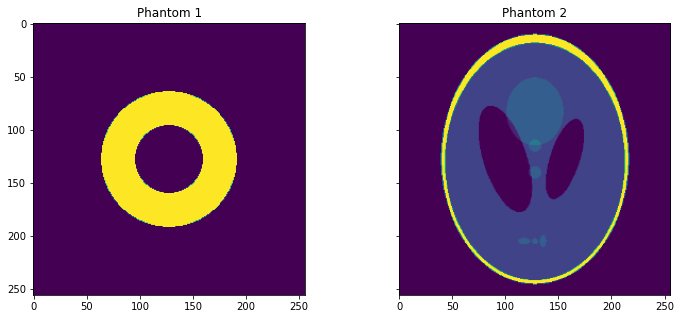

In [6]:
def circular_phantom(N):
    
    lin = np.linspace(-1,1, N)
    [XX, YY] = np.meshgrid(lin, lin)
    RR = np.sqrt(XX**2 + YY**2)
    circ_image = np.zeros((N,N))
    circ_image[RR < 0.5] = 1.
    circ_image[RR < 0.25] = 0.
    
    return circ_image


N = 256
phantom1 = circular_phantom(N)
phantom2 = resize(shepp_logan_phantom(), (N, N),
                       anti_aliasing=True) # Shepp-Logan Phantom

# plot 2D-phantoms

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axs[0].imshow(phantom1)
axs[0].set_title('Phantom 1')
axs[1].imshow(phantom2)
axs[1].set_title('Phantom 2')
plt.show()


**Exercice 1.2.**

Calculez les transformations de Radon pour les fantômes 1 et 2 avec les paramètres ``nshift = 256, ntheta = 128``.
Construisez les graphiques des transformations de Radon calculées en utilisant la fonction `plt.imshow(...)` (dans la littérature tomographique, ces images sont appelées **sinoïdogrammes**). Que pouvez-vous dire à propos de ces fonctions (lissage par rapport au lissage des fantômes, périodicité) - commentez ?

In [ ]:
# YOUR CODE HERE

proj_phantom1 = None
proj_phantom2 = None

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axs[0].imshow(proj_phantom1)
axs[0].set_title('Projections for phantom 1')
axs[1].imshow(proj_phantom2)
axs[1].set_title('Projections for phantom 2')
plt.show()

**Réponse à l'exercice 1.2 :** VOTRE RÉPONSE

<div class="lev1"><a href="#Sommaire"><span class="toc-item-num"></span>Retour au sommaire</a></div>

### 2. Transformation de Radon duale

La transformation de Radon duale peut être calculée en discrétisant la formule pour $R^*$ :

$$
 R^*g (x) = \int\limits_{S^1}g(x\theta, \theta)\, d\theta \approx \Delta \varphi
 \sum_{i=1}^{N_\varphi} g(x\cdot \theta_i), \theta_i), \, \theta_i = \left(\cos\left((i-1)\frac{2\pi}{N_\varphi}\right), \sin\left((i-1)\frac{2\pi}{N_\varphi}\right)\right)
$$

La transformation de Radon $g(s,\theta) = Rf$ est connue uniquement sur l'ensemble $\{s_i\}_{i=1}^{N_s}\times \{\theta_i\}_{i=1}^{N_\theta}$, donc dans la formule ci-dessus, tous les termes ne sont pas connus (le problème se situe dans la variable $s$). Cependant, dans ce cas, ils peuvent être obtenus par interpolation unidimensionnelle (linéaire) sur l'ensemble $\{\theta_i\}\times [-1,1]$.

On peut voir de la formule que l'interpolation doit être effectuée selon la variable unidimensionnelle $s$, les données pour $\theta_i$ étant connues. Comme nous allons calculer $R^*g$ sur une grille discrète $\{x_j\}_{j=1}^{N^2}$ dans $[-1,1]^2$, il est le plus efficace d'effectuer l'interpolation immédiatement sur tout le tableau de points $\{x_j \cdot \theta_i\}_{j=1}^{N^2}$ pour chaque $\theta_i$.

Pour l'interpolation unidimensionnelle, on peut utiliser la fonction ``numpy.interp(interp_points, points, values, left, right)``, où ``interp_points`` sont les coordonnées des points pour l'interpolation, ``points`` sont les coordonnées des points connus, ``values`` sont les valeurs de la fonction aux points connus, et ``left, right`` sont les valeurs limites si les coordonnées d'interpolation sortent des données connues.

#### Remarque sur l'interpolation

Formellement, on peut se demander quel type d'interpolation choisir ? En plus de l'interpolation linéaire, il existe de nombreux autres types : trigonométrique, quadratique, polynomiale, par splines et autres.

Il est nécessaire de prendre en compte deux facteurs :

  * La fonction $g(s,\theta)$ (souvent, mais pas toujours) appartient à l'image de la transformation de Radon, c'est-à-dire que $g = Rf$ pour une certaine fonction $f$, donc l'interpolation doit "respecter" l'image $\mathrm{Im}(R)$. Cela signifie que les valeurs interpolées ne doivent pas sortir de l'image $\mathrm{Im}(R)$ - une telle interpolation présente certaines difficultés en raison des caractéristiques de la description de $\mathrm{Im}(R)$ et, dans cette tâche, nous n'allons pas nous occuper de ce problème (mais d'un autre côté, si vous êtes intéressé, cela peut être discuté).

  * L'opérateur $R$ est un lissage, en d'autres termes, les fonctions dans l'image sont plus lisses que leurs pré-images. Par conséquent, en général, pour interpoler $g(s,\theta)$, il faut choisir des méthodes d'interpolation de plus haut ordre que la classe de régularité dans le domaine de définition. Par exemple, si nous supposons que l'argument $f$ appartient à la classe $C^1$, alors l'interpolation linéaire pour $g(s,\theta)$ n'est pas suffisante et nous devons choisir, par exemple, une interpolation quadratique.

En fin de compte, il est nécessaire de voir ce que nous voulons obtenir dans le problème spécifique. Pour nos exemples "de base", l'interpolation linéaire est tout à fait suffisante. De plus, en raison du choix d'une grille assez dense, l'erreur liée au "sortie" de l'image n'est pas non plus très grande. Il est intéressant de noter que nous ne prenons en compte aucun de ces points, mais cela doit être tenu en compte, car en cas de problèmes numériques et d'apparition d'artefacts, l'interpolation peut être une des causes.

**Tâche 2.1**

Implémentez la fonction ``adjradon2d(proj, npixels, radius)``, qui calcule la transformation de Radon adjointe à partir des données projection. Les paramètres d'entrée sont les suivants :

* ``proj`` - une matrice de données de projection de taille ``(ntheta, nshift)``

* ``radius`` - la distance maximale du zéro aux bords du support

* ``npixels`` - le nombre de pixels sur le segment `[-radius, radius]`

Paramètres de sortie : une matrice/image de taille `npixels x npixels`

In [2]:
def adjradon2d(proj, ngrid, radius):
    
    adjradon = np.zeros((npixels, npixels))
    
    # YOUR CODE HERE
    return adjradon

**Exercice 2.2**

Calculez et construisez les images $R^*Rf$ pour les fantômes 1 et 2 de l'Exercice 1.2.
Quelles différences par rapport aux images originales des fantômes observez-vous ? (lissage, singularité, contours, compacité du support, etc.) Pouvez-vous expliquer ce résultat ?

In [ ]:
# YOUR CODE HERE

adj_phantom1 = None
adj_phantom2 = None

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axs[0].imshow(adj_phantom1)
axs[0].set_title('R*Rf for Phantom 1')
axs[1].imshow(adj_phantom2)
axs[1].set_title('R*Rf for Phantom 2')
plt.show()

**Réponse à l'exercice 2.2 :** VOTRE RÉPONSE

<div class="lev1"><a href="#Sommaire"><span class="toc-item-num"></span>Retour au sommaire</a></div>

### 3. Représentation matricielle de la transformation de Radon

### 3.1 Matrice de transformation $R$
Étant donné que nous supposons que l'image est une fonction localement constante avec des valeurs constantes à l'intérieur de ses pixels, l'intégrale le long d'un rayon peut être écrite sous la forme de la somme finie suivante :

\begin{equation}
    Rf(s_i, \theta_j) = \sum\limits_{k=1}^{N_p} f_k L_k(s_i, \theta_j),
\end{equation}

où $f_k$ est la valeur de $f$ dans le pixel $k$, et $L_k(s_i, \theta_j)$ est la longueur de l'intersection de la ligne $(s_i, \theta_j)$ avec le pixel $k$.

<center>
<img src="matrix-model.png" width="450" heigth="400">
</center>
<center>Transformation de Radon de l'image $f$. Ici, $f$ est représenté sous forme d'une matrice $f_{ij}$, <br>
mais nous allons la considérer comme un tableau linéaire unidimensionnel.</center>

En se basant sur la formule ci-dessus, la transformation de Radon peut être vue comme le produit d'un vecteur par une matrice :

\begin{equation}
    Rf = Lf, \text{ où } L \text{ est la matrice des longueurs d'intersection } \{L_k\}, \, L \in 
    \mathrm{Mat}_{N_sN_\theta, N_p}(\mathbb{R}),
\end{equation}

où $f$ est un vecteur de dimension $N_p = N^2$ correspondant à notre image.

Ainsi, $R$ est un opérateur linéaire $R : \mathbb{R}^{N_p} \rightarrow \mathbb{R}^{N_sN_\theta}$. Cet opérateur peut être étudié du point de vue de l'algèbre linéaire et de l'analyse numérique, ce que nous ferons dans la section suivante. Pour commencer, nous allons calculer la matrice $R$.

**Exercice 3.1**

1. Exprimez $L_k (s_i, \theta_j)$ en termes de la transformation de Radon d'une certaine fonction $f$. Quelle est cette fonction pour un pixel arbitraire $k$ ? Nous considérerons des images de taille $64 \times 64$ pixels, avec $N_s = 64$ et $N_\theta=64$. Quelle est la taille de la matrice $R$ correspondant à ces paramètres ?

2. Implémentez ci-dessous la fonction `matrixradon2d(npixels, ntheta, nshifts, radius=1.0)`, qui retourne la matrice $R$ pour les images $N$. Essayez d'évaluer la complexité de votre algorithme en notation $O(\dots), \Omega(\dots)$.

3. Calculez les transformations de Radon des phantômes 1 et 2 du paragraphe 1 à l'aide de cette matrice, comparez les résultats avec ceux obtenus précédemment (construisez des graphiques des "différences" entre les images).

4. **(question facultative et difficile)** L'approximation matricielle de la transformation de Radon est-elle une approximation au sens de la norme des opérateurs dans les espaces de dimension infinie ? Par exemple, les valeurs singulières de la matrice $R$ approchent-elles les valeurs singulières de l'opérateur $R$ ? (Si vous ne pouvez pas le démontrer formellement, donnez au moins votre intuition.) Cette question est liée à une question très simple : **ces recherches numériques ont-elles un sens et sont-elles correctes, alors que tout opérateur linéaire dans un espace de dimension infinie ne peut pas être approché par une matrice ?**

Pour vous aider, utilisez l'ébauche du programme `matrixradon2d(...)` dans la cellule ci-dessous.

<div class="lev1"><a href="#Sommaire"><span class="toc-item-num"></span>Retour au sommaire</a></div>

In [ ]:
# npixels - pixels per image dimension, N x N = npixels x npixels
# ntheta  - number of projections
# nshifts - number of lines per projection

def matrixradon2d(npixels, ntheta, nshift, radius=1.0):
    
    radon_matrix = np.zeros((ntheta*nshift, npixels**2))
    
    #1. init geometry/sizes  
    dx = 2.0*radius / npixels # pixel's sidelength
    shifts = np.linspace(-radius + dx/2, radius-dx/2, nshift)
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint = False)
    
    # 2. YOUR CODE HERE
    for i_pixel in range(npixels**2):
        
        # 2.1 pixel's coordinates
        pixel_coords = np.array([-radius + dx/2 + dx*(i_pixel % npixels),  
                                  radius - dx/2 - dx*(i_pixel // npixels)])
        
        # 2.2 create one-pixel image 
        image = np.zeros(npixels**2)
        image[i_pixel] = 1.0
        image = np.reshape(image, (npixels, npixels))
    
        # 2.3 compute matrix projection vector 
        proj_vector = np.zeros((ntheta, nshift))
        
        for i_theta in range(ntheta):
            # 2.4 find shifts that are needed for computation for the pixel, others are 0's
            ...
            
        # return column
        radon_matrix[:, i_pixel] = np.reshape(proj_vector, ntheta*nshift)
    
    return radon_matrix

In [20]:
# YOUR CODE HERE 

radon2d_matrix_64 = None

In [ ]:
# RUN THE CELL

# computation of low-resolution projections and plotting

# 1. low-resolution phantoms, f
N = 64
phantom1_64 = np.reshape(circular_phantom(N), (N**2,1))
phantom2_64 = np.reshape(tomopy.misc.phantom.shepp2d(N), (N**2,1))

# 2. low-resolution projections, projection = R * f, * - matrix vector product
proj_phantom1_64 = np.reshape(np.dot(radon2d_matrix_64, phantom1_64), (64, 64))
proj_phantom2_64 = np.reshape(np.dot(radon2d_matrix_64, phantom2_64), (64, 64))

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axs[0].imshow(proj_phantom1_64)
axs[1].imshow(proj_phantom2_64)
plt.show()

**Réponses aux points 1-4 de l'exercice 3.1 :** VOTRE RÉPONSE

**Exercice 3.2**

Construisez une image bidimensionnelle de la matrice en utilisant la fonction ``plt.imshow(...)``.
La matrice de transformation $R$ est-elle creuse ? Estimez leur nombre et donnez une explication.

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(12, 12), sharey=True)
im = axs.imshow(radon2d_matrix_64)
axs.set_title('Matrix R')
plt.show()

**Réponse à l'exercice 3.2 :** VOTRE RÉPONSE

### 3.2 Matrice de transformation $R^*$

Pour calculer la transformation radon duale $R^*$, il est nécessaire de discrétiser l'intégrale mentionnée dans l'introduction, c'est-à-dire d'utiliser une discrétisation sur $S^1$. Alors, la formule approchée pour $R^*g$ peut être écrite comme suit :

\begin{equation}
    R^*g(x) = \int\limits_{S^1} g(x\theta, \theta)\, d\theta \approx 
    \Delta_\varphi \sum_{i=1}^{N_{\varphi}} g(x\theta_i, \theta_i)
\end{equation}

La transformation $R^*$ est un opérateur linéaire, donc on peut également écrire et calculer sa matrice de la même manière que pour $R$.

**Exercice 3.3**

1. Implémentez un programme qui calcule la matrice de transformation $R^*$ sous forme de programme `matrixadjradon2d(...)`, de manière similaire à l'exercice précédent (réfléchissez au point 2 avant d'effectuer cette tâche).

2. Représentez cette matrice en utilisant la fonction `plt.imshow(...)`. Réfléchissez à la relation entre les matrices de transformation $R$ et $R^*$ ? (Indice : $R^*$ et $R$ sont des opérateurs duaux formels par rapport à la norme $L^2$).

In [ ]:
def matrixadjradon2d(npixels, ntheta, nshift, radius=1.0):
    # YOUR CODE HERE
    return None

adjradon2d_matrix_64 = matrixadjradon2d(64, 64, 64)
fig, axs = plt.subplots(1, 1, figsize=(12, 12), sharey=True)
im = axs.imshow(adjradon2d_matrix_64) 
axs.set_title('R* matrix')
fig.colorbar(im, ax=axs)
plt.show()

**Exercice 3.4**

Construisez les images $R^*Rf$ pour les fonctions $f$ correspondant aux phantômes 1 et 2. Ainsi, vérifiez la correction de votre algorithme en comparant les images obtenues avec celles de l'exercice 2.2.

In [ ]:
# YOUR CODE HERE

normal_phantom1_64 = None
normal_phantom2_64 = None

fig, axs = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

axs[0].imshow(np.reshape(normal_phantom1_64, (64, 64)))
axs[0].set_title('matrix-op R*Rf for phantom 1')
axs[1].imshow(np.reshape(normal_phantom2_64, (64, 64)))
axs[1].set_title('matrix-op R*Rf for phantom 2')
plt.show()

### 4. L'utilisation des représentations matricielles pour l'inversion des transformations de Radon. Stabilité des réconstructions

Examinons la question mathématique de l'inversion de la transformation de Radon. Supposons que nous connaissons la transformation $g = Rf$ et que nous avons la matrice $R$, il nous faut alors restaurer $f$. Il est évident que ce problème est équivalent à la résolution d'une équation linéaire :

\begin{equation}
    Rf = g.
\end{equation}

La fonction dans NumPy qui résout un système linéaire est `np.linalg.solve(A, b)`, où $A$ est la matrice et $b$ est le vecteur de données. Si la matrice $A$ est singulière ($\det A = 0$ avec une précision machine), on peut chercher une solution au sens des moindres carrés :

$$
    f^{+} = \arg \min_f \|Rf-g\|^2
$$

Cette solution existe toujours et est unique. La fonction $f^{+}$ est appelée la solution généralisée, et est connue sous le nom de pseudo-inverse de $g$ au sens de Moore-Penrose. La fonction correspondante dans Numpy est `np.linalg.lstsq(...)`.

**Exercice 4.1**

1. En utilisant la matrice de transformation $R$ de l'exercice 3 et les données projectives pour les fantômes 1 et 2 de l'exercice 2, restaurez les images des fantômes. Étant donné que même pour de petites tailles d'images le calcul de la matrice $R$ dépasse les capacités des ordinateurs personnels, effectuez les calculs pour de petites résolutions d'images et de sinogrammes (par exemple, des images de $64 \times 64$ pixels, un sinogramme de taille $64 \times 64$).

2. Appliquez la formule de projection inverse FBP (filtered backprojection algorithm) pour restaurer les fantômes 1 et 2. La fonction `iradon(...)` se trouve dans la bibliothèque `skimage.transform`, des exemples d'utilisation peuvent être trouvés ici <a href="https://scikit-image.org/docs/dev/auto_examples/transform/plot_radon_transform.html"><span class="toc-item-num"></span>Skimage Radon transform</a>.

3. *Pouvez-vous expliquer la différence entre les restaurations en utilisant la matrice $R$ et l'algorithme FBP ?*

In [ ]:
# YOUR CODE HERE

# 1. plot phantoms

# 2. compute/plot least-squares solutions

# 3. compute/plot filtered backprojection reconstructions

from skimage.transform import iradon

recon1_64_fbp = iradon(proj_phantom1_64[0:31, :].transpose())
recon2_64_fbp = iradon(proj_phantom2_64[0:31, :].transpose())

Comme nous le savons à partir de la première leçon, la transformation de Radon $R$ peut être inversée, ou autrement dit que $R$ est injective, ce qui revient à dire qu'il existe un opérateur inverse à gauche $R^{-1}$.

Mais comment vérifier numériquement si la matrice $R$ est inversible ?

Si la matrice $R$ était carrée, l'une des caractérisations possibles de l'injectivité de $R$ serait le déterminant :

\begin{equation}
    \det(R) = 0 \Leftrightarrow \text{la transformation } R \text{ n'est pas injective}.
\end{equation}

La fonction pour calculer le déterminant est ``np.linalg.det(A)``.

#### Exercice 4.2

Calculez le déterminant de la matrice $R$ ? (choisissez les paramètres pour lesquels elle est carrée). Comment pouvez-vous expliquer / commenter le résultat obtenu ?

In [ ]:
# YOUR CODE HERE


**Réponse à l'exercice 4.2 :** VOTRE RÉPONSE

Ainsi, dans notre cas, lorsque la matrice $R$ est carrée, le déterminant est égal à 0. Peut-il se produire que le déterminant soit numériquement égal à 0, mais que l'opérateur soit injectif ? Il n'est pas difficile de comprendre que cela peut se produire (du point de vue numérique), donc nous avons besoin d'un autre critère numérique pour l'injectivité.

À partir des exemples précédents, nous savons que la matrice $R$ peut ne pas être carrée (il suffit, par exemple, de prendre plus de données radiales). Comment peut-on alors étudier numériquement l'injectivité de l'opérateur ?

Voici un résultat qui vient à notre secours et que nous formulons sous la forme d'une lemme (la démonstration vous est laissée en exercice).

**Exercice 4.3 - Lemme.**

Soit $A$ un opérateur linéaire borné entre les espaces de Hilbert $H, K$. Démontrez que $A$ est injectif si et seulement si l'opérateur $A^*A$ est injectif.

En nous basant sur ce lemme, nous pouvons considérer la matrice symétrique $R^*R$ et étudier son injectivité - pour les opérateurs symétriques (auto-adjoints), la théorie est beaucoup plus riche. Par exemple, on peut utiliser le résultat suivant :

\begin{equation}
   \text{la matrice } R \text{ est non singulière } \Leftrightarrow \text{tous les valeurs propres de }R^*R \text{ sont non nuls}
\end{equation}

Les valeurs propres de l'opérateur $R^*R$ sont appelées **valeurs singulières** de l'opérateur $R$. Les valeurs singulières d'une matrice quelconque peuvent être trouvées en utilisant la fonction NumPy ``U, S, V = np.linalg.svd(A)``, où $S$ est un tableau des valeurs singulières ordonnées par ordre décroissant, et $U, V$ sont des matrices orthogonales (rappelons que le décomposition en valeurs singulières de la matrice $R$ est sa représentation sous la forme $U^TSV = R$, où $U,V$ sont orthogonales et $S$ est une matrice diagonale).

**Exercice 4.4**
Construisez un graphique des valeurs singulières de l'opérateur $R$. Comment cela aide-t-il à répondre à la question posée dans l'exercice 4.2 ?

In [ ]:
# YOUR CODE HERE


**Exercice 4.5* (facultatif, mais intéressant)**
En se basant sur le graphique des valeurs singulières de $R$, quelle hypothèse peut-on faire en termes d'analyse fonctionnelle concernant l'opérateur $R$, si on le considère comme linéaire et continu entre des espaces de Hilbert de dimension infinie ?

Ainsi, comme nous le voyons, les valeurs singulières décroissent assez rapidement. On peut estimer qualitativement la vitesse de décroissance des valeurs propres en construisant un graphique à l'échelle logarithmique (si vous êtes intéressé, essayez de construire ce graphique et d'estimer la vitesse de décroissance).

### 4.1 Problème de stabilité

Dans le cours d'analyse numérique, vous avez peut-être été familiarisé avec les aspects et problèmes liés à l'inversion des matrices. Que se passera-t-il si nous essayons de reconstruire les images des fantômes à partir de 1 ou 2 données projectionnelles $g = Rf$, si $Rf$ est connu avec une certaine erreur ?

Cette situation est facilement imaginable en pratique, lorsque des mesures sont effectuées et que l'appareil donne une certaine erreur lors de la mesure.

Par exemple, si l'erreur est additive et gaussienne (ce qui est tout à fait réaliste pour certaines applications, par exemple, lorsque les mains de l'expérimentateur tremblent (nous ne préciserons pas pourquoi)), nous obtenons le modèle de mesures suivant :

\begin{equation}
        g = Rf + \varepsilon, \text{ où } \varepsilon \text{ i.i.d } \mathcal{N}(0, \sigma^2)
\end{equation}

Comment le bruit $\varepsilon$ (dans ce cas gaussien $\mathcal{N}(0,\sigma^2)$) affectera-t-il la qualité des reconstructions ? Dans quelle mesure les reconstructions seront-elles modifiées en présence de bruit ?

#### Modélisation des erreurs dans les données $Rf$

Ajoutons un bruit gaussien de 5% aux données $Rf$, c'est-à-dire considérons le modèle de données suivant :

\begin{equation}
    g(s_i, \theta_j) = Rf(s_i, \theta_j) + \varepsilon_{ij} \text{ où } \varepsilon \text{ i.i.d } \mathcal{N}(0, \sigma^2), 
\end{equation}
où $\sigma = 0.5 \cdot \max_{ij}{|Rf(s_i, \theta_j)|}$.

In [ ]:
sigma1 = 0.05 * np.max(proj_phantom1_64[:])
sigma2 = 0.05 * np.max(proj_phantom2_64[:])

noisy_proj_phantom1_64 = proj_phantom1_64 + np.random.normal(0, sigma1, proj_phantom1_64.shape) 
noisy_proj_phantom2_64 = proj_phantom2_64 + np.random.normal(0, sigma2, proj_phantom2_64.shape) 

fig, axs = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

axs[0].imshow(noisy_proj_phantom1_64)
axs[1].imshow(noisy_proj_phantom2_64)
plt.show()

Comme on peut le voir, les données ne sont pas fortement altérées. Essayons maintenant de reconstruire les images des fantômes à partir de ces données bruitées.

**Exercice 4.6**

Reconstruisez les images à partir des données bruitées en utilisant la méthode des moindres carrés et la rétroprojection filtrée (FBP). Comment pouvez-vous expliquer le résultat obtenu ? Comparez les tailles des objets visibles sur la sinogramme et l'image reconstruite. Où sont les détails plus fins visibles ?

In [ ]:
# YOUR CODE HERE 

# 1. least-squares

# 2. FBP


**Réponse à l'exercice 4.6 :** VOTRE RÉPONSE

<div class="lev1"><a href="#Sommaire"><span class="toc-item-num"></span>Retour au sommaire</a></div>

### 5. Stabilisation par DSV

Dans la tâche précédente, nous avons découvert que la matrice de transformation $R$ est singulière, ce qui signifie que le problème de rétablissement de $f$ à partir de $Rf$ ne peut pas être interprété dans un sens ordinaire. En fin de compte, nous avons cherché une solution généralisée $f^+$.

En effet, $R^{-1}$ ne peut plus être un opérateur borné (lorsqu'on applique $R^{-1}$ à certains vecteurs $g$, le résultat $R^{-1}g$ peut "exploser").

**Mais pourquoi la méthode des moindres carrés fonctionne-t-elle, et pourquoi donne-t-elle des résultats insatisfaisants en présence de bruit ?**

L'algorithme ``np.linalg.lstsq(...)`` rétablit la fonction $f$ par la méthode des moindres carrés. Il est facile de montrer que ce problème est équivalent à la résolution du système d'équations linéaires suivant :

\begin{equation}
    R^*Rf = R^*g.
\end{equation}

L'opérateur $R^*R$ est auto-adjoint, donc il a une base de vecteurs propres où les valeurs propres sont précisément les valeurs singulières de l'opérateur $R$. Soit $\{u_i\}_{i=1}^{n}, \{\sigma_i\}_{i=1}^{n}$ une base orthonormée de vecteurs propres, alors la fonction $f$ et $g$ peuvent être décomposées dans cette base et en utilisant l'équation ci-dessus, nous obtenons la décomposition de la fonction $f$ :

\begin{equation}
    \langle f, u_i \rangle = \dfrac{\langle R^*g, u_i \rangle}{\sigma_i}.
\end{equation}

Ainsi, plus $\sigma_i$ est petit, plus le rétablissement de la i-ème composante de $f$ est instable. En effet, supposons que nous ajoutions un bruit gaussien avec des composantes indépendantes $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ à $g$. Alors, au lieu de la vraie i-ème composante, nous rétablissons la quantité :

\begin{equation}
    \langle \tilde{f}, u_i \rangle := \dfrac{\langle R^*g, u_i \rangle}{\sigma_i} + \dfrac{\varepsilon}{\sigma_i}
    = f_i + \dfrac{\varepsilon}{\sigma_i}.
\end{equation}

En raison du fait que le bruit $\varepsilon$ est uniformément projeté sur tous les vecteurs propres $\{u_i\}$, pour de petits $\sigma_i$, le terme $\varepsilon / \sigma_i$ peut considérablement déformer nos rétablissements. Les spécialistes des problèmes inverses disent que dans ce cas, le bruit $\varepsilon$ a une **composante haute fréquence**. D'un autre côté, si $\sigma << \sigma_i$, le rétablissement de la i-ème composante du signal est stable.

C'est pourquoi dans les rétablissements précédents, les distorsions étaient assez significatives. On peut essayer d'améliorer la qualité des rétablissements en ne rétablissant pas toutes les composantes : celles dont $\sigma_i$ sont suffisamment grandes peuvent être tentées de rétablir, tandis que celles qui sont petites peuvent être simplement éliminées car elles dégradent notre signal et il n'est pas possible de les rétablir de manière stable.

\begin{equation}
    f = \sum_{i=1}^{n_0} u_i \dfrac{\langle R^*g, u_i \rangle}{\sigma_i}, n < n_0.
\end{equation}

Dans la tâche 4.4, nous avons construit un graphique des valeurs singulières, de sorte que nous pouvons choisir $n_0$ empiriquement. La question du choix automatique de $n_0$ est le sujet de nombreuses recherches et la réponse dépend de nombreux paramètres (valeurs singulières, modèle de bruit, critère d'optimalité). Dans la littérature, la formule de rétablissement avec "troncature" jusqu'à l'indice $n_0$ est appelée régularisation basée sur la décomposition en valeurs singulières.

**Exercice 5.1**

En utilisant la fonction ``np.linalg.lstsq(...)`` (voir la documentation), rétablissez les signaux pour différents valeurs de $n_0$ et appliquez-le aux données bruitées du exercice précédent. Trouvez la valeur de $n_0$ pour laquelle les rétablissements sont visuellement les meilleurs. (Indice : la régularisation est gérée par le paramètre `rcond` dans la fonction mentionnée.)

In [ ]:
# YOUR CODE HERE


Du point de vue de l'analyse numérique, la stabilité de l'inversion d'une matrice est caractérisée par le **nombre de conditionnement** $\mathrm{cond}(A) = \dfrac{\sigma_{\max}}{\sigma_{\min}}$, où $\sigma_{\max}$ et $\sigma_{\min}$ sont respectivement la plus grande et la plus petite valeur singulière. Plus le nombre de conditionnement est élevé, moins la solution numérique du système d'équations linéaires est stable. L'exemple de l'exercice 5.1 illustre cette instabilité, et il est facile de remarquer que dans notre cas $\mathrm{cond}(R) = +\infty$ (à la précision machine). Ainsi, en "tronquant" les petites valeurs singulières, nous réduisons le nombre de conditionnement.

Dans la suite du cours, nous rencontrerons à plusieurs reprises le problème de la stabilité. La théorie des opérateurs pseudo-différentiels nous permettra de caractériser l'asymptotique du nombre de conditionnement et d'accélérer certains algorithmes matriciels. Cela peut être extrêmement utile dans les applications, notamment dans la conception de nouveaux scanners, tomographes et autres instruments de reconstruction de signaux.

<div class="lev1"><a href="#Sommaire"><span class="toc-item-num"></span>Retour au sommaire</a></div>

### Travaux supplémentaires / Travaux à domicile

1. Trouver le paramètre optimal de régularisation `rcond` dans le dernier exercice. Comment dépend-il du niveau de bruit ? Essayez d'augmenter le niveau de bruit, comment change le paramètre de régularisation ?

2. Implémenter la fonction `radon_siddon(...)`, qui calcule rapidement (en O(N)) et avec précision la transformation de Radon sur un plan. Lien vers l'algorithme : [Siddon](https://ieeexplore.ieee.org/document/1352469)

3. Implémenter les fonctions `radon(...)` et `radon_adjoint(...)` pour la transformation de Radon en trois dimensions (il est fortement recommandé d'utiliser activement les fonctions vectorielles **NumPy** pour augmenter la vitesse des calculs).